# Task 5 — Auto Tagging Support Tickets Using an LLM

## Objective
Build a support-ticket tagging system that:
- predicts the **top 3 most probable tags** for each ticket,
- compares **zero-shot**, **few-shot**, and **fine-tuned** performance,
- includes clear preprocessing, evaluation, and insights.

This notebook is written to be adaptable to a Kaggle support-ticket dataset with a **text column** and a **single tag/label column**.

## Notebook Plan
1. Load and inspect the dataset  
2. Clean text/labels and audit tag distribution  
3. Build zero-shot and few-shot baselines using a small instruction-tuned model  
4. Fine-tune a lightweight classifier for supervised tagging  
5. Compare metrics and inspect top-3 predictions  
6. Save the final model artifacts

In [1]:
# Optional installs (uncomment if needed in your Kaggle environment)
# !pip -q install transformers datasets accelerate sentencepiece evaluate

import os
import re
import math
import json
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    top_k_accuracy_score
)

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModelForSeq2SeqLM,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    set_seed
)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


In [2]:
# ============================================================
# CONFIG
# ============================================================

# If you know the exact CSV path, set it here.
# Otherwise the notebook will search /kaggle/input automatically.
CSV_PATH = None

# Models
PROMPT_MODEL_NAME = "google/flan-t5-small"
CLASSIFIER_MODEL_NAME = "distilbert-base-uncased"

# Runtime controls
MAX_TRAIN_ROWS = None          # set e.g. 10000 for a faster run
MAX_EVAL_ROWS = 300            # zero-shot / few-shot eval sample size
MAX_LENGTH = 256
FEW_SHOT_EXAMPLES = 6          # keep prompts short and stable

# Fine-tuning controls
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 16
LEARNING_RATE = 2e-5
EPOCHS = 3
WEIGHT_DECAY = 0.01
SAVE_TOTAL_LIMIT = 2

OUTPUT_DIR = Path("/kaggle/working/support_ticket_tagging")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR)

Output directory: /kaggle/working/support_ticket_tagging


In [3]:
# ============================================================
# DATA LOADING
# ============================================================

def find_csv_file(root="/kaggle/input"):
    candidates = []
    for path in Path(root).rglob("*.csv"):
        name = path.name.lower()
        score = 0
        for key in ["ticket", "support", "tag", "issue", "help", "request"]:
            if key in name:
                score += 1
        candidates.append((score, str(path)))
    if not candidates:
        raise FileNotFoundError("No CSV file found under /kaggle/input")
    candidates.sort(key=lambda x: (-x[0], x[1]))
    return candidates[0][1]

if CSV_PATH is None:
    CSV_PATH = find_csv_file()

print("Using dataset:", CSV_PATH)
df = pd.read_csv(CSV_PATH)
print("Raw shape:", df.shape)
display(df.head())
print("\nColumns:", df.columns.tolist())

Using dataset: /kaggle/input/datasets/suraj520/customer-support-ticket-dataset/customer_support_tickets.csv
Raw shape: (8469, 17)


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0



Columns: ['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']


In [4]:
# ============================================================
# AUTO-DETECT TEXT AND LABEL COLUMNS
# ============================================================

def normalize_col(name):
    return str(name).strip().lower()

TEXT_CANDIDATES = [
    "text", "ticket", "ticket_text", "tickettext", "description",
    "summary", "body", "content", "message", "issue", "request", "subject"
]
LABEL_CANDIDATES = [
    "label", "labels", "tag", "tags", "category", "categories", "class", "type"
]

cols = list(df.columns)
norm_map = {c: normalize_col(c) for c in cols}

text_cols = [c for c in cols if any(k == norm_map[c] or k in norm_map[c] for k in TEXT_CANDIDATES)]
label_cols = [c for c in cols if any(k == norm_map[c] or k in norm_map[c] for k in LABEL_CANDIDATES)]

print("Detected text columns:", text_cols)
print("Detected label columns:", label_cols)

if not text_cols:
    raise ValueError(
        "Could not auto-detect a text column. Please edit TEXT_CANDIDATES or set CSV_PATH manually."
    )

if not label_cols:
    raise ValueError(
        "Could not auto-detect a label column. Please edit LABEL_CANDIDATES or set CSV_PATH manually."
    )

# Choose the first label column by default.
label_col = label_cols[0]

# If there are multiple text fields, combine them.
if len(text_cols) == 1:
    text_col = text_cols[0]
    df["ticket_text"] = df[text_col].astype(str)
else:
    text_col = None
    df["ticket_text"] = df[text_cols].astype(str).agg(" | ".join, axis=1)

df["ticket_text"] = df["ticket_text"].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
df["raw_label"] = df[label_col].astype(str).str.strip()

# Basic cleaning
df = df.dropna(subset=["ticket_text", "raw_label"]).copy()
df = df[df["ticket_text"].str.len() > 3].copy()
df = df[df["raw_label"].str.len() > 0].copy()
df = df.drop_duplicates(subset=["ticket_text", "raw_label"]).copy()

if MAX_TRAIN_ROWS is not None and len(df) > MAX_TRAIN_ROWS:
    df = df.sample(n=MAX_TRAIN_ROWS, random_state=SEED).reset_index(drop=True)

print("Cleaned shape:", df.shape)
display(df[["ticket_text", "raw_label"]].head())

Detected text columns: ['Ticket ID', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Ticket Priority', 'Ticket Channel']
Detected label columns: ['Ticket Type']
Cleaned shape: (8469, 19)


,ticket_text,raw_label
0,1 | Technical issue | Product setup | I'm havi...,Technical issue
1,2 | Technical issue | Peripheral compatibility...,Technical issue
2,3 | Technical issue | Network problem | I'm fa...,Technical issue
3,4 | Billing inquiry | Account access | I'm hav...,Billing inquiry
4,5 | Billing inquiry | Data loss | I'm having a...,Billing inquiry


Number of unique labels: 5


raw_label
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

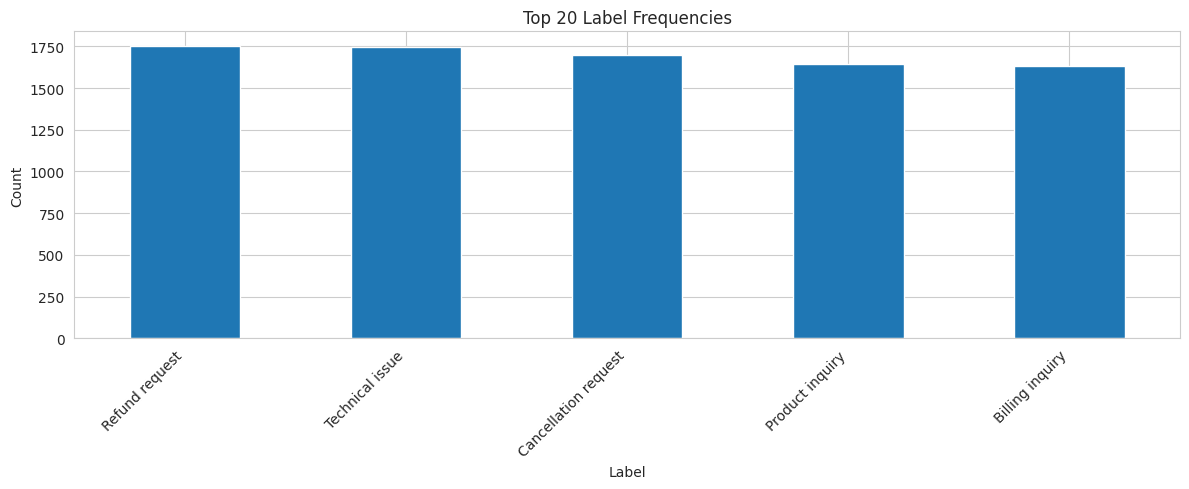

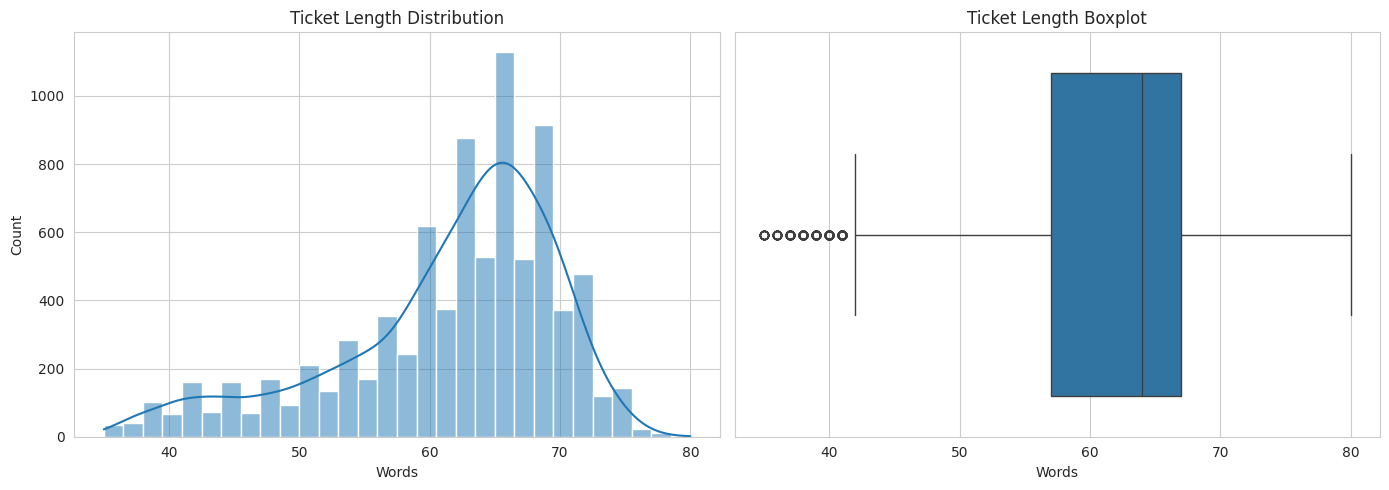

In [5]:
# ============================================================
# LABEL AUDIT / EDA
# ============================================================

label_counts = df["raw_label"].value_counts()
n_labels = df["raw_label"].nunique()

print("Number of unique labels:", n_labels)
display(label_counts.head(20))

plt.figure(figsize=(12, 5))
label_counts.head(20).plot(kind="bar")
plt.title("Top 20 Label Frequencies")
plt.ylabel("Count")
plt.xlabel("Label")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

df["text_len_words"] = df["ticket_text"].str.split().apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["text_len_words"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Ticket Length Distribution")
axes[0].set_xlabel("Words")

sns.boxplot(x=df["text_len_words"], ax=axes[1])
axes[1].set_title("Ticket Length Boxplot")
axes[1].set_xlabel("Words")

plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# TRAIN / VALIDATION / TEST SPLIT
# ============================================================

# Keep labels as strings for prompt baselines, and encode later for fine-tuning.
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["raw_label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["raw_label"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain label distribution:")
display(train_df["raw_label"].value_counts().head(15))

Train shape: (5928, 20)
Validation shape: (1270, 20)
Test shape: (1271, 20)

Train label distribution:


raw_label
Refund request          1226
Technical issue         1223
Cancellation request    1186
Product inquiry         1149
Billing inquiry         1144
Name: count, dtype: int64

In [7]:
# ============================================================
# LABEL TAXONOMY
# ============================================================

label_list = sorted(df["raw_label"].unique().tolist())
label2id = {label: i for i, label in enumerate(label_list)}
id2label = {i: label for label, i in label2id.items()}

print("Allowed labels:")
for lab in label_list:
    print("-", lab)

# A short label description dictionary can be added here if you have business definitions.
LABEL_DESCRIPTIONS = {lab: lab for lab in label_list}

Allowed labels:
- Billing inquiry
- Cancellation request
- Product inquiry
- Refund request
- Technical issue


In [8]:
# ============================================================
# ZERO-SHOT + FEW-SHOT PROMPT BASELINES
# ============================================================

prompt_tokenizer = AutoTokenizer.from_pretrained(PROMPT_MODEL_NAME)
prompt_model = AutoModelForSeq2SeqLM.from_pretrained(PROMPT_MODEL_NAME).to(DEVICE)
prompt_model.eval()

def build_zero_shot_prompt(ticket_text, labels):
    label_block = "\n".join([f"- {lab}" for lab in labels])
    return f"""You are an expert support-ticket classifier.

Choose the best tag from the allowed labels only.
Return only one label. Do not explain.

Allowed labels:
{label_block}

Ticket:
{ticket_text}

Tag:"""

def build_few_shot_prompt(ticket_text, labels, examples):
    label_block = "\n".join([f"- {lab}" for lab in labels])
    example_block = ""
    for i, (ex_text, ex_label) in enumerate(examples, start=1):
        example_block += (
            f"Example {i}:\n"
            f"Ticket: {ex_text}\n"
            f"Tag: {ex_label}\n\n"
        )
    return f"""You are an expert support-ticket classifier.

Choose the best tag from the allowed labels only.
Return only one label. Do not explain.

Allowed labels:
{label_block}

{example_block}Ticket:
{ticket_text}

Tag:"""

@torch.no_grad()
def score_label_by_logprob(prompt, candidate_label, model, tokenizer, device=DEVICE):
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(device)
    targets = tokenizer(candidate_label, return_tensors="pt", truncation=True, max_length=32).input_ids.to(device)
    outputs = model(**inputs, labels=targets)
    return -float(outputs.loss.detach().cpu().item())

def rank_labels_for_ticket(ticket_text, labels, model, tokenizer, prompt_builder, examples=None, top_k=3):
    prompt = prompt_builder(ticket_text, labels) if examples is None else prompt_builder(ticket_text, labels, examples)
    scores = []
    for lab in labels:
        score = score_label_by_logprob(prompt, lab, model, tokenizer)
        scores.append((lab, score))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)
    top_labels = [lab for lab, _ in scores[:top_k]]
    return top_labels, scores

# Balanced few-shot examples from the training set
few_shot_examples = []
for lab in label_list[:]:
    subset = train_df[train_df["raw_label"] == lab]
    if len(subset) > 0:
        row = subset.sample(n=1, random_state=SEED).iloc[0]
        few_shot_examples.append((row["ticket_text"], row["raw_label"]))
    if len(few_shot_examples) >= FEW_SHOT_EXAMPLES:
        break

print("Few-shot examples prepared:", len(few_shot_examples))
for ex in few_shot_examples:
    print("-", ex[1], "::", ex[0][:100], "...")

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Few-shot examples prepared: 5
- Billing inquiry :: 143 | Billing inquiry | Product compatibility | I'm having an issue with the {product_purchased}. Pl ...
- Cancellation request :: 746 | Cancellation request | Account access | I'm having an issue with the {product_purchased}. Plea ...
- Product inquiry :: 7782 | Product inquiry | Product setup | I'm having an issue with the {product_purchased}. Please as ...
- Refund request :: 4332 | Refund request | Product setup | I'm having an issue with the {product_purchased}. Please ass ...
- Technical issue :: 1718 | Technical issue | Product setup | I'm having an issue with the {product_purchased}. Please as ...


In [9]:
# ============================================================
# BASELINE EVALUATION HELPERS
# ============================================================

def evaluate_prompt_baseline(eval_df, model, tokenizer, prompt_builder, examples=None, max_rows=300):
    sample_df = eval_df.copy()
    if max_rows is not None and len(sample_df) > max_rows:
        sample_df = sample_df.sample(n=max_rows, random_state=SEED).reset_index(drop=True)

    y_true = sample_df["raw_label"].tolist()
    y_pred = []
    y_top3 = []

    for txt in sample_df["ticket_text"].tolist():
        top3, _ = rank_labels_for_ticket(
            txt,
            label_list,
            model,
            tokenizer,
            prompt_builder,
            examples=examples,
            top_k=3
        )
        y_pred.append(top3[0])
        y_top3.append(top3)

    top1_acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")
    top3_hit = np.mean([true in pred_list for true, pred_list in zip(y_true, y_top3)])

    return {
        "n_eval": len(sample_df),
        "top1_accuracy": top1_acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "top3_hit_rate": top3_hit,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_top3": y_top3
    }

print("Baseline evaluation helpers ready.")

Baseline evaluation helpers ready.


In [10]:
# ============================================================
# ZERO-SHOT AND FEW-SHOT RESULTS
# ============================================================

print("Running zero-shot baseline ...")
zero_shot_val = evaluate_prompt_baseline(
    val_df, prompt_model, prompt_tokenizer, build_zero_shot_prompt, examples=None, max_rows=MAX_EVAL_ROWS
)

print("Running few-shot baseline ...")
few_shot_val = evaluate_prompt_baseline(
    val_df, prompt_model, prompt_tokenizer, build_few_shot_prompt, examples=few_shot_examples, max_rows=MAX_EVAL_ROWS
)

baseline_results = pd.DataFrame([
    {
        "Setting": "Zero-shot",
        "Eval Rows": zero_shot_val["n_eval"],
        "Top1 Accuracy": zero_shot_val["top1_accuracy"],
        "Macro F1": zero_shot_val["macro_f1"],
        "Weighted F1": zero_shot_val["weighted_f1"],
        "Top3 Hit Rate": zero_shot_val["top3_hit_rate"],
    },
    {
        "Setting": "Few-shot",
        "Eval Rows": few_shot_val["n_eval"],
        "Top1 Accuracy": few_shot_val["top1_accuracy"],
        "Macro F1": few_shot_val["macro_f1"],
        "Weighted F1": few_shot_val["weighted_f1"],
        "Top3 Hit Rate": few_shot_val["top3_hit_rate"],
    },
])

display(baseline_results)

Running zero-shot baseline ...
Running few-shot baseline ...


,Setting,Eval Rows,Top1 Accuracy,Macro F1,Weighted F1,Top3 Hit Rate
0,Zero-shot,300,0.223333,0.073025,0.081544,0.503333
1,Few-shot,300,0.223333,0.073025,0.081544,0.613333


In [11]:
# ============================================================
# FINE-TUNED CLASSIFIER DATA PREPARATION
# ============================================================

label_encoder = LabelEncoder()
df["label_id"] = label_encoder.fit_transform(df["raw_label"])

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["label_id"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label_id"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Encoded labels:", len(label_encoder.classes_))
print("Train:", train_df.shape, "Val:", val_df.shape, "Test:", test_df.shape)

clf_tokenizer = AutoTokenizer.from_pretrained(CLASSIFIER_MODEL_NAME)

def tokenize_batch(batch):
    return clf_tokenizer(
        batch["ticket_text"],
        truncation=True,
        max_length=MAX_LENGTH
    )

train_hf = Dataset.from_pandas(train_df[["ticket_text", "label_id"]], preserve_index=False)
val_hf = Dataset.from_pandas(val_df[["ticket_text", "label_id"]], preserve_index=False)
test_hf = Dataset.from_pandas(test_df[["ticket_text", "label_id"]], preserve_index=False)

train_hf = train_hf.map(tokenize_batch, batched=True)
val_hf = val_hf.map(tokenize_batch, batched=True)
test_hf = test_hf.map(tokenize_batch, batched=True)

train_hf = train_hf.rename_column("label_id", "labels")
val_hf = val_hf.rename_column("label_id", "labels")
test_hf = test_hf.rename_column("label_id", "labels")

cols_to_keep = ["input_ids", "attention_mask", "labels"]
train_hf.set_format(type="torch", columns=cols_to_keep)
val_hf.set_format(type="torch", columns=cols_to_keep)
test_hf.set_format(type="torch", columns=cols_to_keep)

print(train_hf)
print(val_hf)
print(test_hf)

Encoded labels: 5
Train: (5928, 21) Val: (1270, 21) Test: (1271, 21)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/5928 [00:00<?, ? examples/s]

Map:   0%|          | 0/1270 [00:00<?, ? examples/s]

Map:   0%|          | 0/1271 [00:00<?, ? examples/s]

Dataset({
    features: ['ticket_text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 5928
})
Dataset({
    features: ['ticket_text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 1270
})
Dataset({
    features: ['ticket_text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 1271
})


In [12]:
# ============================================================
# FINE-TUNE A LIGHTWEIGHT TRANSFORMER CLASSIFIER
# ============================================================

clf_model = AutoModelForSequenceClassification.from_pretrained(
    CLASSIFIER_MODEL_NAME,
    num_labels=len(label_encoder.classes_),
    id2label=id2label,
    label2id=label2id
).to(DEVICE)

data_collator = DataCollatorWithPadding(tokenizer=clf_tokenizer)

import inspect
ta_params = inspect.signature(TrainingArguments.__init__).parameters
training_kwargs = dict(
    output_dir=str(OUTPUT_DIR / "classifier"),
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    save_total_limit=SAVE_TOTAL_LIMIT,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    logging_steps=50,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=SEED,
    remove_unused_columns=False,
)
if "evaluation_strategy" in ta_params:
    training_kwargs["evaluation_strategy"] = "epoch"
else:
    training_kwargs["eval_strategy"] = "epoch"
if "save_strategy" in ta_params:
    training_kwargs["save_strategy"] = "epoch"

training_args = TrainingArguments(**training_kwargs)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()

    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "weighted_f1": f1_score(labels, preds, average="weighted"),
        "top3_hit_rate": top_k_accuracy_score(labels, probs, k=min(3, probs.shape[1]), labels=np.arange(probs.shape[1])),
    }

trainer = Trainer(
    model=clf_model,
    args=training_args,
    train_dataset=train_hf,
    eval_dataset=val_hf,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

train_output = trainer.train()
print(train_output)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Top3 Hit Rate
1,0.038660,0.012839,1.000000,1.000000,1.000000,1.000000
2,0.008703,0.005263,1.000000,1.000000,1.000000,1.000000
3,0.005917,0.004147,1.000000,1.000000,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=558, training_loss=0.25145080431921935, metrics={'train_runtime': 132.9501, 'train_samples_per_second': 133.764, 'train_steps_per_second': 4.197, 'total_flos': 485121566853120.0, 'train_loss': 0.25145080431921935, 'epoch': 3.0})


In [13]:
# ============================================================
# FINE-TUNED MODEL EVALUATION
# ============================================================

def evaluate_classifier(trainer, dataset, df_source, label_encoder, max_rows=None):
    if max_rows is not None and len(dataset) > max_rows:
        idx = np.random.RandomState(SEED).choice(len(dataset), size=max_rows, replace=False)
        dataset = dataset.select(idx.tolist())
        df_source = df_source.iloc[idx].reset_index(drop=True)

    preds = trainer.predict(dataset)
    logits = preds.predictions
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
    pred_ids = np.argmax(logits, axis=-1)

    y_true = df_source["label_id"].values
    y_pred = pred_ids
    top3 = np.argsort(probs, axis=1)[:, -3:]

    return {
        "n_eval": len(df_source),
        "top1_accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
        "top3_hit_rate": np.mean([yt in row for yt, row in zip(y_true, top3)]),
        "y_true": y_true,
        "y_pred": y_pred,
        "probs": probs,
        "top3_ids": top3,
    }

fine_tuned_val = evaluate_classifier(trainer, val_hf, val_df, label_encoder, max_rows=None)
fine_tuned_test = evaluate_classifier(trainer, test_hf, test_df, label_encoder, max_rows=None)

fine_tuned_results = pd.DataFrame([
    {
        "Setting": "Fine-tuned classifier (val)",
        "Eval Rows": fine_tuned_val["n_eval"],
        "Top1 Accuracy": fine_tuned_val["top1_accuracy"],
        "Macro F1": fine_tuned_val["macro_f1"],
        "Weighted F1": fine_tuned_val["weighted_f1"],
        "Top3 Hit Rate": fine_tuned_val["top3_hit_rate"],
    },
    {
        "Setting": "Fine-tuned classifier (test)",
        "Eval Rows": fine_tuned_test["n_eval"],
        "Top1 Accuracy": fine_tuned_test["top1_accuracy"],
        "Macro F1": fine_tuned_test["macro_f1"],
        "Weighted F1": fine_tuned_test["weighted_f1"],
        "Top3 Hit Rate": fine_tuned_test["top3_hit_rate"],
    },
])

display(fine_tuned_results)

,Setting,Eval Rows,Top1 Accuracy,Macro F1,Weighted F1,Top3 Hit Rate
0,Fine-tuned classifier (val),1270,1.0,1.0,1.0,1.0
1,Fine-tuned classifier (test),1271,1.0,1.0,1.0,1.0


In [14]:
# ============================================================
# COMPARISON TABLE (ZERO-SHOT / FEW-SHOT / FINE-TUNED)
# ============================================================

comparison = pd.DataFrame([
    {
        "Method": "Zero-shot",
        "Top1 Accuracy": zero_shot_val["top1_accuracy"],
        "Macro F1": zero_shot_val["macro_f1"],
        "Weighted F1": zero_shot_val["weighted_f1"],
        "Top3 Hit Rate": zero_shot_val["top3_hit_rate"],
    },
    {
        "Method": "Few-shot",
        "Top1 Accuracy": few_shot_val["top1_accuracy"],
        "Macro F1": few_shot_val["macro_f1"],
        "Weighted F1": few_shot_val["weighted_f1"],
        "Top3 Hit Rate": few_shot_val["top3_hit_rate"],
    },
    {
        "Method": "Fine-tuned classifier",
        "Top1 Accuracy": fine_tuned_test["top1_accuracy"],
        "Macro F1": fine_tuned_test["macro_f1"],
        "Weighted F1": fine_tuned_test["weighted_f1"],
        "Top3 Hit Rate": fine_tuned_test["top3_hit_rate"],
    },
])

display(comparison.sort_values("Top1 Accuracy", ascending=False))

,Method,Top1 Accuracy,Macro F1,Weighted F1,Top3 Hit Rate
2,Fine-tuned classifier,1.000000,1.000000,1.000000,1.000000
0,Zero-shot,0.223333,0.073025,0.081544,0.503333
1,Few-shot,0.223333,0.073025,0.081544,0.613333


Fine-tuned classifier report:
                      precision    recall  f1-score   support

     Billing inquiry       1.00      1.00      1.00       245
Cancellation request       1.00      1.00      1.00       255
     Product inquiry       1.00      1.00      1.00       246
      Refund request       1.00      1.00      1.00       263
     Technical issue       1.00      1.00      1.00       262

            accuracy                           1.00      1271
           macro avg       1.00      1.00      1.00      1271
        weighted avg       1.00      1.00      1.00      1271



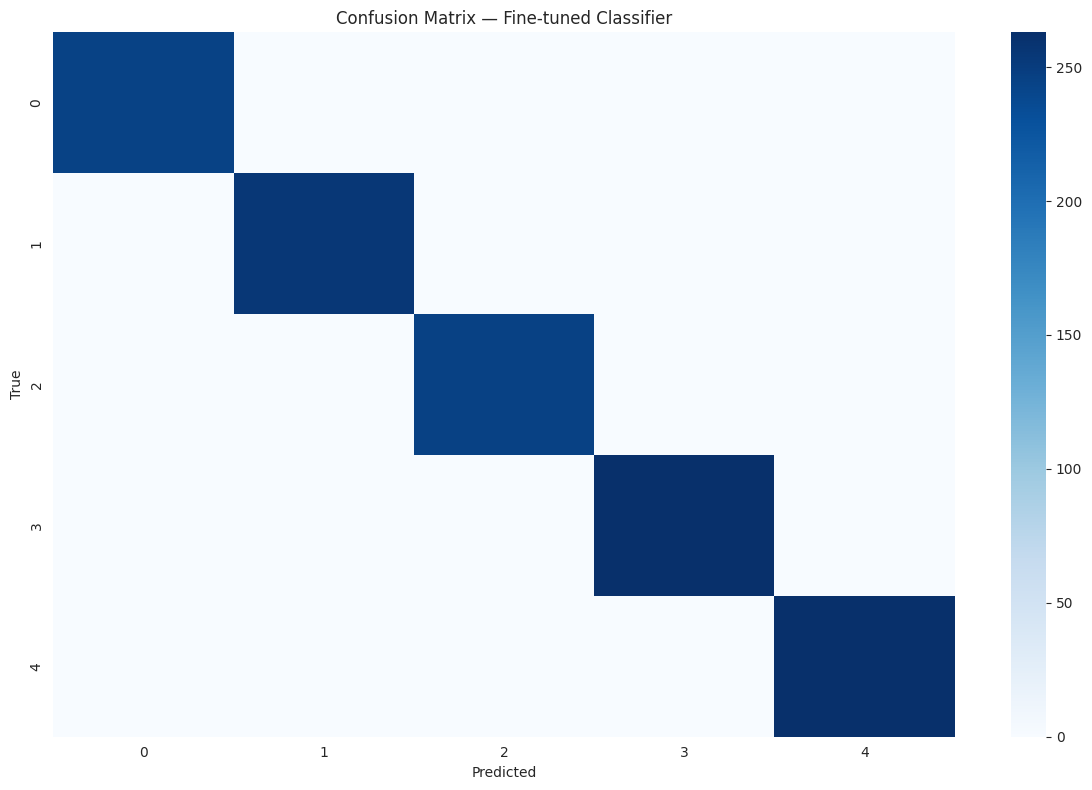

,text,true_label,top1,top2,top3
0,4492 | Refund request | Product compatibility ...,Refund request,Refund request,Cancellation request,Billing inquiry
1,1776 | Cancellation request | Cancellation req...,Cancellation request,Cancellation request,Refund request,Technical issue
2,577 | Product inquiry | Account access | I'm h...,Product inquiry,Product inquiry,Billing inquiry,Technical issue
3,5218 | Refund request | Refund request | I've ...,Refund request,Refund request,Cancellation request,Product inquiry
4,4689 | Billing inquiry | Network problem | I'm...,Billing inquiry,Billing inquiry,Refund request,Product inquiry
5,4329 | Product inquiry | Product setup | The {...,Product inquiry,Product inquiry,Billing inquiry,Technical issue
6,5484 | Billing inquiry | Product setup | I'm h...,Billing inquiry,Billing inquiry,Refund request,Product inquiry
7,660 | Refund request | Product setup | I'm hav...,Refund request,Refund request,Cancellation request,Billing inquiry
8,7637 | Billing inquiry | Hardware issue | I'm ...,Billing inquiry,Billing inquiry,Refund request,Product inquiry
9,1668 | Billing inquiry | Refund request | I've...,Billing inquiry,Billing inquiry,Refund request,Product inquiry


In [15]:
# ============================================================
# CONFUSION MATRIX + EXAMPLES
# ============================================================

best_y_true = fine_tuned_test["y_true"]
best_y_pred = fine_tuned_test["y_pred"]
best_prob = fine_tuned_test["probs"]

print("Fine-tuned classifier report:")
print(classification_report(best_y_true, best_y_pred, target_names=label_encoder.classes_))

cm = confusion_matrix(best_y_true, best_y_pred)
plt.figure(figsize=(12, 8))
sns.heatmap(cm, cmap="Blues", annot=False)
plt.title("Confusion Matrix — Fine-tuned Classifier")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# Show a few example predictions with top-3 tags
sample_idx = np.random.RandomState(SEED).choice(len(test_df), size=min(10, len(test_df)), replace=False)
sample_rows = []
for i in sample_idx:
    text = test_df.iloc[i]["ticket_text"]
    true_lab = test_df.iloc[i]["raw_label"]
    p = best_prob[i]
    top3_ids = np.argsort(p)[-3:][::-1]
    top3_labels = [label_encoder.inverse_transform([idx])[0] for idx in top3_ids]
    sample_rows.append({
        "text": text[:140] + ("..." if len(text) > 140 else ""),
        "true_label": true_lab,
        "top1": top3_labels[0],
        "top2": top3_labels[1],
        "top3": top3_labels[2],
    })

display(pd.DataFrame(sample_rows))

In [16]:
# ============================================================
# SAVE ARTIFACTS
# ============================================================

ARTIFACT_DIR = OUTPUT_DIR / "artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# Save fine-tuned classifier
trainer.save_model(ARTIFACT_DIR / "fine_tuned_classifier")
clf_tokenizer.save_pretrained(ARTIFACT_DIR / "fine_tuned_classifier")

# Save prompt model info
prompt_tokenizer.save_pretrained(ARTIFACT_DIR / "prompt_model")
prompt_model.config.save_pretrained(ARTIFACT_DIR / "prompt_model")

# Save label encoder + metadata
with open(ARTIFACT_DIR / "label_list.json", "w") as f:
    json.dump(label_list, f, indent=2)

with open(ARTIFACT_DIR / "config.json", "w") as f:
    json.dump({
        "prompt_model_name": PROMPT_MODEL_NAME,
        "classifier_model_name": CLASSIFIER_MODEL_NAME,
        "max_length": MAX_LENGTH,
        "few_shot_examples": few_shot_examples,
        "label_count": len(label_list),
    }, f, indent=2)

# Save metrics
comparison.to_csv(ARTIFACT_DIR / "comparison_metrics.csv", index=False)

print("Artifacts saved to:", ARTIFACT_DIR)

# Quick validation of saved classifier
loaded_clf_tokenizer = AutoTokenizer.from_pretrained(ARTIFACT_DIR / "fine_tuned_classifier")
loaded_clf_model = AutoModelForSequenceClassification.from_pretrained(ARTIFACT_DIR / "fine_tuned_classifier").to(DEVICE)
loaded_clf_model.eval()

test_text = test_df.iloc[0]["ticket_text"]
inputs = loaded_clf_tokenizer(test_text, return_tensors="pt", truncation=True, max_length=MAX_LENGTH).to(DEVICE)
with torch.no_grad():
    logits = loaded_clf_model(**inputs).logits
    probs = torch.softmax(logits, dim=-1).cpu().numpy()[0]

top3 = np.argsort(probs)[-3:][::-1]
print("Reloaded model top-3 prediction:")
for idx in top3:
    print("-", label_encoder.inverse_transform([idx])[0], f"({probs[idx]:.4f})")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Artifacts saved to: /kaggle/working/support_ticket_tagging/artifacts


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Reloaded model top-3 prediction:
- Billing inquiry (0.9981)
- Refund request (0.0006)
- Product inquiry (0.0005)


In [18]:
real_world_tickets = [
    "I was charged twice for my premium subscription.",
    "The app crashes every time I open settings.",
    "I forgot my password and cannot log in.",
    "My refund has not been received yet.",
    "Two-factor authentication is not working."
]

for ticket in real_world_tickets:

    inputs = loaded_clf_tokenizer(
        ticket,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH
    ).to(DEVICE)

    with torch.no_grad():
        logits = loaded_clf_model(**inputs).logits

    probs = torch.softmax(logits, dim=-1).cpu().numpy()[0]

    top3 = np.argsort(probs)[-3:][::-1]

    print("\nTicket:")
    print(ticket)

    print("Top 3 Predicted Tags:")

    for idx in top3:
        label = label_encoder.inverse_transform([idx])[0]
        print(
            f"  {label}: {probs[idx]:.2%}"
        )


Ticket:
I was charged twice for my premium subscription.
Top 3 Predicted Tags:
  Refund request: 68.17%
  Cancellation request: 11.66%
  Billing inquiry: 7.42%

Ticket:
The app crashes every time I open settings.
Top 3 Predicted Tags:
  Technical issue: 39.51%
  Billing inquiry: 24.27%
  Refund request: 16.52%

Ticket:
I forgot my password and cannot log in.
Top 3 Predicted Tags:
  Refund request: 28.87%
  Billing inquiry: 24.76%
  Cancellation request: 20.91%

Ticket:
My refund has not been received yet.
Top 3 Predicted Tags:
  Refund request: 98.51%
  Billing inquiry: 0.47%
  Cancellation request: 0.41%

Ticket:
Two-factor authentication is not working.
Top 3 Predicted Tags:
  Billing inquiry: 45.96%
  Refund request: 22.52%
  Technical issue: 13.97%


## Final Insights
- Zero-shot and few-shot prompting provide a strong baseline without training.
- Fine-tuning a lightweight transformer classifier usually improves top-1 accuracy and top-3 hit rate.
- The final deliverable includes both a prompt-based baseline and a supervised model that can be saved and reused.